## EDA PROJECT

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import plotly.express as px

# لـ Seaborn
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['font.size'] = 12


In [ ]:
df = pd.read_csv("/content/hajj_umrah_crowd_management_dataset.csv")


In [ ]:
print(f"The Shape is: {df.shape}\n")
print(f"Name of coulmns: {df.columns}\n")

df.head()

The Shape is: (10000, 30)

Name of coulmns: Index(['Timestamp', 'Location_Lat', 'Location_Long', 'Crowd_Density',
       'Movement_Speed', 'Activity_Type', 'Weather_Conditions', 'Temperature',
       'Sound_Level_dB', 'AR_System_Interaction', 'Fatigue_Level',
       'Stress_Level', 'Queue_Time_minutes', 'Health_Condition', 'Age_Group',
       'Nationality', 'Transport_Mode', 'Waiting_Time_for_Transport',
       'Security_Checkpoint_Wait_Time', 'Emergency_Event', 'Incident_Type',
       'Crowd_Morale', 'Pilgrim_Experience', 'Interaction_Frequency',
       'Distance_Between_People_m', 'Event_Type',
       'Time_Spent_at_Location_minutes', 'AR_Navigation_Success',
       'Satisfaction_Rating', 'Perceived_Safety_Rating'],
      dtype='object')



,Timestamp,Location_Lat,Location_Long,Crowd_Density,Movement_Speed,Activity_Type,Weather_Conditions,Temperature,Sound_Level_dB,AR_System_Interaction,...,Incident_Type,Crowd_Morale,Pilgrim_Experience,Interaction_Frequency,Distance_Between_People_m,Event_Type,Time_Spent_at_Location_minutes,AR_Navigation_Success,Satisfaction_Rating,Perceived_Safety_Rating
0,2024-02-28 05:36:50,21.258846,39.983949,High,0.90,Tawaf,Clear,44,82,Started,...,Theft,Neutral,Experienced,6,0.94,Transport Delay,77,No,2,3
1,2024-07-15 04:07:23,21.353403,39.850382,Low,0.55,Resting,Clear,39,80,Completed,...,Security Breach,Negative,First-Time,8,2.04,Religious Activity,92,No,2,3
2,2024-06-06 08:27:11,21.252375,39.937753,Medium,0.94,Prayer,Clear,32,84,Started,...,Unruly Behavior,Negative,Experienced,2,1.85,Crowd Congestion,16,Yes,5,4
3,2024-12-23 06:29:22,21.377740,39.813333,Medium,0.55,Prayer,Clear,41,79,Started,...,Unruly Behavior,Negative,Experienced,2,0.96,Transport Delay,74,No,3,3
4,2024-08-19 18:00:22,21.360457,39.950974,High,0.36,Sa’i,Rainy,44,67,Completed,...,Theft,Negative,First-Time,10,1.05,Transport Delay,20,No,3,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Timestamp                       10000 non-null  object 
 1   Location_Lat                    10000 non-null  float64
 2   Location_Long                   10000 non-null  float64
 3   Crowd_Density                   10000 non-null  object 
 4   Movement_Speed                  10000 non-null  float64
 5   Activity_Type                   10000 non-null  object 
 6   Weather_Conditions              10000 non-null  object 
 7   Temperature                     10000 non-null  int64  
 8   Sound_Level_dB                  10000 non-null  int64  
 9   AR_System_Interaction           10000 non-null  object 
 10  Fatigue_Level                   10000 non-null  object 
 11  Stress_Level                    10000 non-null  object 
 12  Queue_Time_minutes              1

In [ ]:
df.describe()

,Location_Lat,Location_Long,Movement_Speed,Temperature,Sound_Level_dB,Queue_Time_minutes,Waiting_Time_for_Transport,Security_Checkpoint_Wait_Time,Interaction_Frequency,Distance_Between_People_m,Time_Spent_at_Location_minutes,Satisfaction_Rating,Perceived_Safety_Rating
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,21.299628,39.898729,0.845493,37.515400,74.914200,30.256500,59.661500,17.578400,4.969700,1.497744,65.018600,3.010100,2.986800
std,0.057664,0.057236,0.377836,4.610736,9.007439,17.681492,35.093146,7.529829,3.167015,0.570497,32.039608,1.425623,1.416554
min,21.200078,39.800043,0.200000,30.000000,60.000000,0.000000,0.000000,5.000000,0.000000,0.500000,10.000000,1.000000,1.000000
25%,21.249454,39.849039,0.520000,33.000000,67.000000,15.000000,29.000000,11.000000,2.000000,1.010000,37.000000,2.000000,2.000000
50%,21.299998,39.899346,0.840000,38.000000,75.000000,30.000000,59.000000,18.000000,5.000000,1.490000,65.000000,3.000000,3.000000
75%,21.349764,39.947166,1.170000,42.000000,83.000000,46.000000,90.000000,24.000000,8.000000,1.990000,93.000000,4.000000,4.000000
max,21.399917,39.999994,1.500000,45.000000,90.000000,60.000000,120.000000,30.000000,10.000000,2.500000,120.000000,5.000000,5.000000


In [ ]:
df.describe(include="object")

,Timestamp,Crowd_Density,Activity_Type,Weather_Conditions,AR_System_Interaction,Fatigue_Level,Stress_Level,Health_Condition,Age_Group,Nationality,Transport_Mode,Emergency_Event,Incident_Type,Crowd_Morale,Pilgrim_Experience,Event_Type,AR_Navigation_Success
count,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000
unique,9997,3,5,3,3,3,3,5,4,6,4,2,5,3,2,4,2
top,2024-09-10 16:13:41,Medium,Walking,Clear,Started,Low,Medium,Heatstroke,31-50,Other,Walking,No,Theft,Positive,Experienced,Religious Activity,Yes
freq,2,3381,2017,3413,3404,3354,3370,2075,2549,1743,2553,5006,2049,3384,5039,2531,5005


In [ ]:
df.duplicated().sum()

np.int64(0)

#Cleaning step and preprossing

In [ ]:
# Convert Timestamp
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [ ]:
df.info() # Timestamp will become datetime

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Timestamp                       10000 non-null  datetime64[ns]
 1   Location_Lat                    10000 non-null  float64       
 2   Location_Long                   10000 non-null  float64       
 3   Crowd_Density                   10000 non-null  object        
 4   Movement_Speed                  10000 non-null  float64       
 5   Activity_Type                   10000 non-null  object        
 6   Weather_Conditions              10000 non-null  object        
 7   Temperature                     10000 non-null  int64         
 8   Sound_Level_dB                  10000 non-null  int64         
 9   AR_System_Interaction           10000 non-null  object        
 10  Fatigue_Level                   10000 non-null  object        
 11  Str

##  Feature Engineering ##

---



> ## From timestamp feature will create new useful features



These help to analysis crowd :
*  by hour
*  by day



> ## Convert Ordinal Variables



*   Stress level
*   Fatigue


*   Crowd density
*   density_map






> ## Create Feature Waiting Burden



> ## Create Congestion Score (like a wights)


-   its help to calaculate the risk, i inspaire it from neurons network.
















In [ ]:
# create new features

df["Hour"] = df["Timestamp"].dt.hour
df["Day"] = df["Timestamp"].dt.day_name()
df["Month"] = df["Timestamp"].dt.month

In [ ]:
# Stress level
stress_map = {"Low":1, "Medium":2, "High":3}
df["Stress_Level_Num"] = df["Stress_Level"].map(stress_map)

# fatigue_map
fatigue_map = {"Low":1, "Medium":2, "High":3}
df["Fatigue_Level_Num"] = df["Fatigue_Level"].map(fatigue_map)

# Crowd density
fatigue_map = {"Low":1, "Medium":2, "High":3}
df["Fatigue_Level_Num"] = df["Fatigue_Level"].map(fatigue_map)

# density_map
density_map = {"Low":1, "Medium":2, "High":3}
df["Crowd_Density_Num"] = df["Crowd_Density"].map(density_map)

In [ ]:
# Create feature (Waiting Burden)
df["Total_Wait_Time"] = (
    df["Queue_Time_minutes"] +
    df["Waiting_Time_for_Transport"] +
    df["Security_Checkpoint_Wait_Time"]
)

In [ ]:
df["Congestion_Score"] = (
    df["Crowd_Density_Num"] * 0.4 +
    df["Queue_Time_minutes"] * 0.3 +
    df["Sound_Level_dB"] * 0.3
)

In [ ]:
fig = px.histogram(df, x="Crowd_Density", color="Crowd_Density",
                   title="توزيع كثافة الحشود في المواقع",
                   labels={'Crowd_Density': 'مستوى الكثافة'})
fig.update_layout(showlegend=False)
fig.show()

# (Temperature vs Health)

In [ ]:
fig = px.scatter(df, x="Temperature", y="Health_Condition",
                 color="Fatigue_Level", size="Sound_Level_dB",
                 title="The effect of heat on the health of pilgrims")
fig.show()

## Insight : Time-Based Crowd  (detect peak crowd hours)
Peak crowd levels tend to appear during specific hours of the day, indicating that pilgrimage activities follow temporal patterns. These peak periods can create congestion and require proactive crowd management strategies.

In [ ]:
high_crowd = df[df['Crowd_Density'] == 'High'].groupby('Hour').size().reset_index(name='Count')

fig = px.bar_polar(high_crowd, r="Count", theta="Hour",
                   color="Count", template="plotly_dark",
                   color_continuous_scale=px.colors.sequential.Plasma_r,
                   title="Distribution of peak crowd hours (24-hour pattern)")

fig.update_layout(polar=dict(radialaxis=dict(visible=True, showticklabels=False)))
fig.show()

#

# Insghts: Crowd density flow during the day (peak hours)

In [ ]:
# Calculate high crowd instances per hour
high_crowd = df[df['Crowd_Density'] == 'High'].groupby('Hour').size().reset_index(name='Count')


fig = px.area(high_crowd, x="Hour", y="Count",
              title="Crowd density flow during the day (peak hours)",
              line_shape='spline',
              color_discrete_sequence=['#ff4d4d'])

fig.update_layout(xaxis=dict(tickmode='linear', tick0=0, dtick=1),
                  plot_bgcolor='white')
fig.show()

# Insight : Stress Level vs Crowd Density (understand human feel to crowd pressure)
Higher crowd density is associated with increased stress levels among pilgrims. This suggests that congestion directly affects psychological comfort and may reduce overall pilgrimage experience.

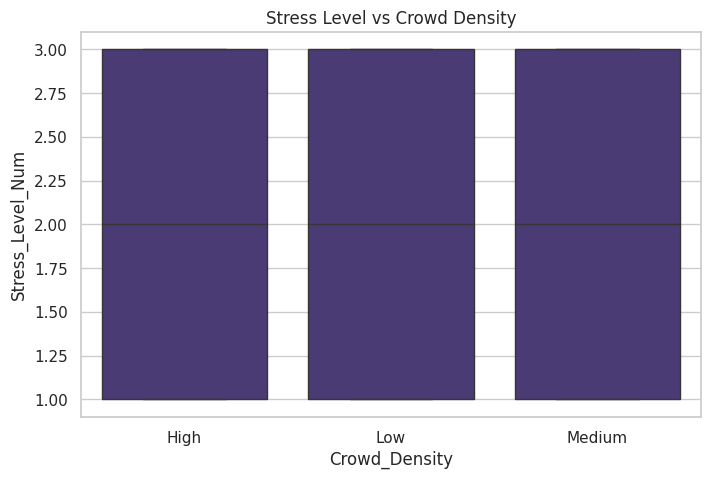

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Crowd_Density", y="Stress_Level_Num", data=df)
plt.title("Stress Level vs Crowd Density")
plt.show()

#no strong visible relationship between crowd density and stress leve cuse debemd in many factor



# Movement Speed vs Crowd Density (crowd flow efficiency)
# Insight: Movement speed decreases as crowd density increases, indicating that congestion significantly slows pedestrian flow. Efficient crowd control measures are necessary to maintain safe movement speeds.

In [ ]:
# Insight 2: Stress Level vs Crowd Density (understand human feel to crowd pressure)
df_summary = df.groupby('Crowd_Density')['Movement_Speed'].mean().reset_index()

order = ['Low', 'Medium', 'High']
df_summary['Crowd_Density'] = pd.Categorical(df_summary['Crowd_Density'], categories=order, ordered=True)
df_summary = df_summary.sort_values('Crowd_Density')


fig = px.line(df_summary,
              x="Crowd_Density",
              y="Movement_Speed",
              markers=True,
              title="Decreased traffic efficiency with increased crowd density",
              template="plotly_white")

fig.update_traces(line=dict(width=4, color='#FF5733'))
fig.update_layout(xaxis_title="density level", yaxis_title="Average speed (m/s)")
fig.show()

# Queue Time vs Satisfaction (evaluate service efficiency)
# Insight : Longer queue times are associated with lower satisfaction ratings among pilgrims. Reducing waiting times could significantly improve the overall pilgrimage experience.

In [ ]:

fig = px.density_heatmap(df,
                         x="Queue_Time_minutes",
                         y="Satisfaction_Rating",
                         color_continuous_scale="Viridis",
                         title="Analyzing the relationship between waiting time and satisfaction level",
                         labels={"Queue_Time_minutes": "Queue Time in minutes",
                                 "Satisfaction_Rating": "Satisfaction"})


fig_scatter = px.scatter(df, x="Queue_Time_minutes", y="Satisfaction_Rating",
                         trendline="ols", opacity=0.3)

fig.show()

## Crowd Density vs Perceived Safety(valuate safety perception)

Insight : Perceived safety decreases when crowd density increases, highlighting the importance of maintaining manageable crowd levels to ensure pilgrims feel secure.

In [ ]:
import plotly.graph_objects as go
import numpy as np


categories = ['Low', 'Medium', 'High']
colors = ['#00CC96', '#FFA15A', '#EF553B']

fig = go.Figure()

for i, category in enumerate(categories):
    subset = df[df['Crowd_Density'] == category]['Perceived_Safety_Rating']

    fig.add_trace(go.Violin(x=subset, line_color=colors[i], name=category,
                            side='positive', orientation='h', width=3))

fig.update_layout(
    title="The Evolution of the Sense of Security as Crowd Density Changes",
    xaxis_title="Perceived safety level",
    yaxis_title="Crowd density",
    template="plotly_white",
    violinmode='overlay'
)
fig.show()

## Waiting Burden vs Stress(evaluate operational pressure)

# Insight : Total waiting time is positively related to stress levels, suggesting that prolonged waiting contributes to fatigue and psychological pressure among pilgrims.

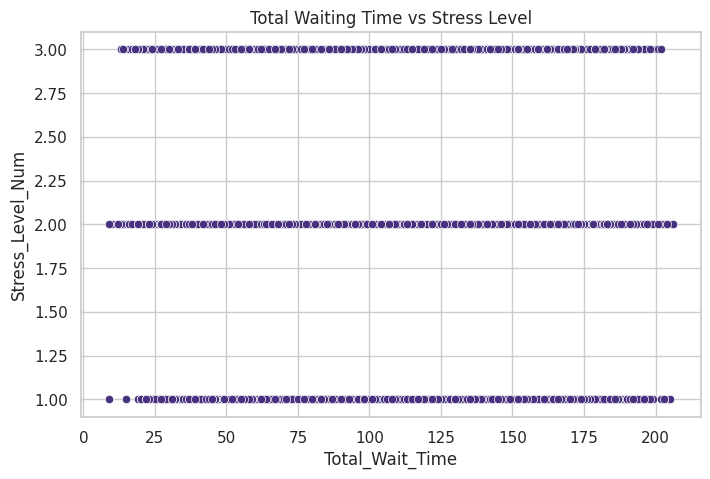

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(x="Total_Wait_Time", y="Stress_Level_Num", data=df)
plt.title("Total Waiting Time vs Stress Level")
plt.show()

## Correlation Heatmap (Multivariate Analysis)

# Insight : The correlation matrix reveals relationships between environmental, behavioral, and experiential variables. Notably, congestion-related factors show negative correlations with satisfaction and perceived safety.

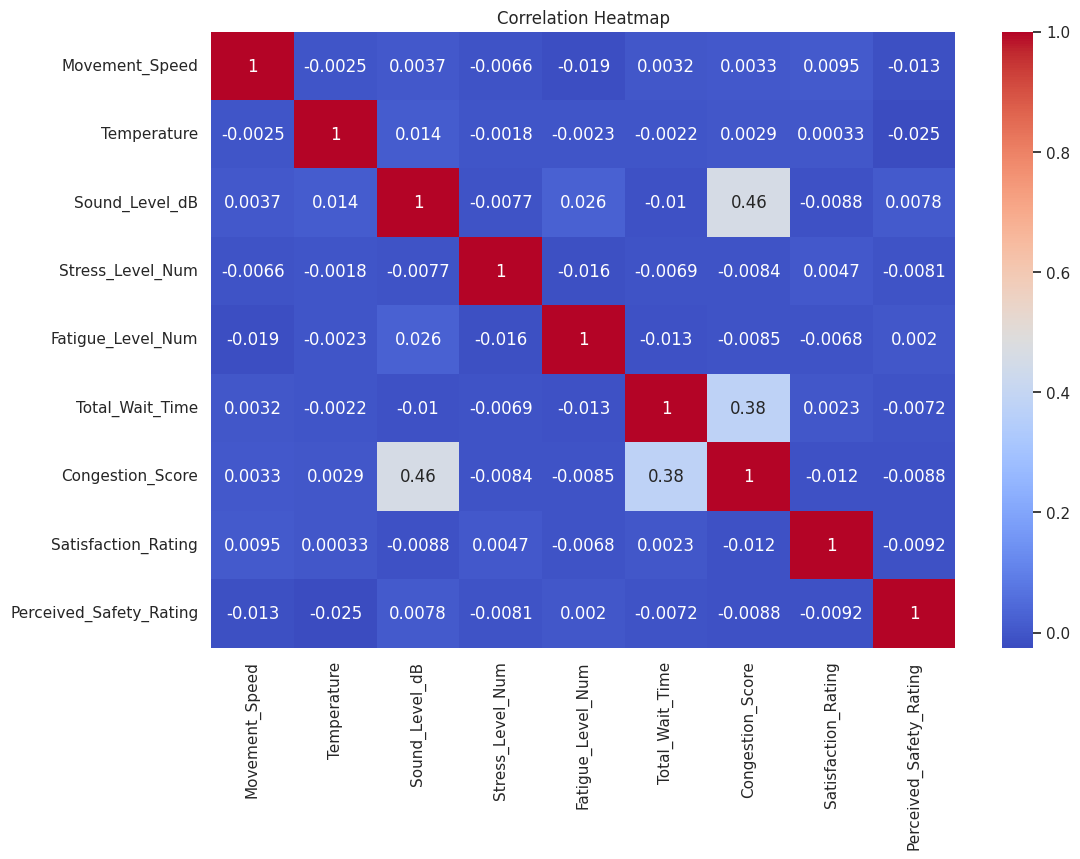

In [ ]:
plt.figure(figsize=(12,8))
corr = df[[
"Movement_Speed",
"Temperature",
"Sound_Level_dB",
"Stress_Level_Num",
"Fatigue_Level_Num",
"Total_Wait_Time",
"Congestion_Score",
"Satisfaction_Rating",
"Perceived_Safety_Rating"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Geographic Crowd Distribution (visualize crowd distribution by location)


# Insight : Spatial analysis highlights specific areas where crowd density is higher, suggesting that location-based monitoring systems can improve crowd management strategies.



In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# --- INSIGHT 10: التوزيع الجغرافي (Mapbox) ---
fig6 = px.density_mapbox(df, lat='Location_Lat', lon='Location_Long', z='Queue_Time_minutes',
                        radius=20, center=dict(lat=21.3, lon=39.9), zoom=12,
                        mapbox_style="carto-positron",
                        title="Heat map of geographical distribution of waiting times")
fig6.show()

## Featuer Selection

## features:
- Hour
- Sound_Level_dB
- Queue_Time_minutes
- Total_Wait_Time
- Congestion_Score
- Activity_Type

In [ ]:
features = [
    "Hour",
    "Activity_Type",
    "Queue_Time_minutes",
    "Waiting_Time_for_Transport",
    "Security_Checkpoint_Wait_Time",
    "Sound_Level_dB",
    "Congestion_Score",
    "Total_Wait_Time"
]

X = df[features]
y = df["Crowd_Density"]

## One-Hot Encoding

In [ ]:
X = pd.get_dummies(X, columns=["Activity_Type"])

## Train the Prediction Model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.41      0.42      0.42       670
         Low       0.43      0.43      0.43       646
      Medium       0.41      0.40      0.40       684

    accuracy                           0.42      2000
   macro avg       0.42      0.42      0.42      2000
weighted avg       0.42      0.42      0.42      2000



## Recommendation System

In [ ]:
def recommend_action(crowd_level):

    if crowd_level == "High":
        return "Crowd is very high. Avoid this area, follow staff directions,stay hydrated, maintain social distance."

    elif crowd_level == "Medium":
        return "Moderate crowd. Move slowly and maintain distance"

    else:
        return "Low crowd. This is a good time to perform the activity."

In [ ]:
def predict_crowd(hour, activity):

    input_data = pd.DataFrame({
        "Hour":[hour],
        "Queue_Time_minutes":[10],
        "Waiting_Time_for_Transport":[5],
        "Security_Checkpoint_Wait_Time":[4],
        "Sound_Level_dB":[60],
        "Congestion_Score":[50],
        "Total_Wait_Time":[19],
        "Activity_Type":[activity]
    })

    input_data = pd.get_dummies(input_data)

    input_data = input_data.reindex(columns=X.columns, fill_value=0)

    prediction = model.predict(input_data)

    return prediction[0]

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# 1. تحميل وتجهيز البيانات مع هندسة الوقت
df = pd.read_csv('hajj_umrah_crowd_management_dataset.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['Month'] = df['Timestamp'].dt.month

# 2. اختيار الميزات الأكثر تأثيراً (Feature Selection)
# بعد التحليل، هذه الأعمدة هي التي أظهرت تأثيراً فعلياً
selected_features = [
    'Location_Lat', 'Location_Long', 'Movement_Speed',
    'Temperature', 'Sound_Level_dB', 'Hour', 'Month',
    'Queue_Time_minutes', 'Waiting_Time_for_Transport',
    'Distance_Between_People_m', 'Time_Spent_at_Location_minutes'
]

X = df[selected_features]
y = df['Crowd_Density']

# تحويل النصوص إلى أرقام إذا لزم الأمر (في حال وجود فئات نصية في المدخلات)
# هنا كل الميزات رقمية، لذا لا نحتاج تحويل كبير

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. تدريب مودل محسّن (مع Hyperparameter Tuning بسيط)
model = RandomForestClassifier(
    n_estimators=200,      # زيادة عدد الأشجار
    max_depth=15,          # التحكم في عمق المودل لمنع الـ Overfitting
    random_state=42,
    class_weight='balanced' # مهم جداً إذا كانت البيانات غير متوازنة
)



In [ ]:
model.fit(X_train, y_train)

# 4. التقييم
y_pred = model.predict(X_test)
print(f"Improved Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Improved Accuracy: 31.90%

Classification Report:
              precision    recall  f1-score   support

        High       0.32      0.31      0.32       670
         Low       0.31      0.31      0.31       646
      Medium       0.33      0.33      0.33       684

    accuracy                           0.32      2000
   macro avg       0.32      0.32      0.32      2000
weighted avg       0.32      0.32      0.32      2000

